In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [4]:
df = pd.read_csv("C:\\Users\\sobha\\Downloads\\Phishing_Email.csv\\Phishing_Email.csv")
df.describe()

,Unnamed: 0
count,18650.000000
mean,9325.154477
std,5384.327293
min,0.000000
25%,4662.250000
50%,9325.500000
75%,13987.750000
max,18650.000000


In [5]:
df.head(10)

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email
5,5,global risk management operations sally congra...,Safe Email
6,6,"On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...",Safe Email
7,7,"entourage , stockmogul newsletter ralph velez ...",Phishing Email
8,8,"we owe you lots of money dear applicant , afte...",Phishing Email
9,9,re : coastal deal - with exxon participation u...,Safe Email


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB
None


In [7]:
df = df.dropna(subset=['Email Text'])

In [8]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as stop_words

def clean_text(text):
    text = re.sub(r'\W', ' ', text)  
    text = text.lower()  
    text = text.split()  
    text = [word for word in text if word not in stop_words]  
    return ' '.join(text)

In [9]:
cleaned_emails = df['Email Text'].apply(clean_text).tolist()

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(cleaned_emails)

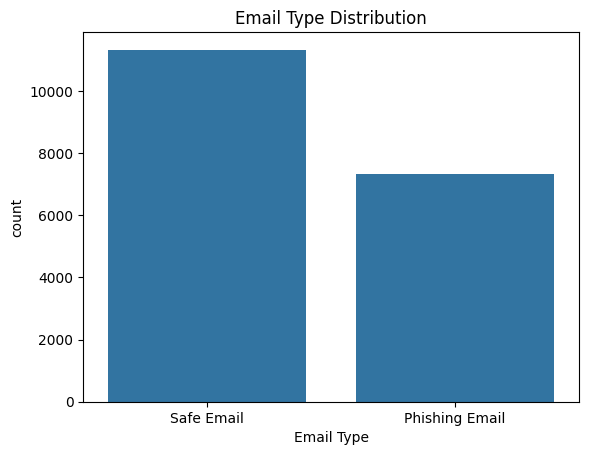

In [11]:
sns.countplot(x='Email Type', data=df)
plt.title('Email Type Distribution')
plt.show()

In [12]:
y = df['Email Type'].map({'Safe Email': 0, 'Phishing Email': 1})

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform

param_dist = {
    'C': uniform(loc=0.01, scale=10), 
    'penalty': ['l1', 'l2'],            
    'solver': ['liblinear', 'saga']     
}
logistic_model = LogisticRegression(max_iter=1000)
random_search = RandomizedSearchCV(logistic_model, param_distributions=param_dist, n_iter=10, cv=5, verbose=2, n_jobs=-1, random_state=42)

random_search.fit(X_train, y_train)
print("The best hyperparameters are:")
print(random_search.best_params_)

print("\nBest result:")
print("Accuracy:", random_search.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
The best hyperparameters are:
{'C': 6.021150117432088, 'penalty': 'l2', 'solver': 'liblinear'}

Best result:
Accuracy: 0.9712886960587184


In [15]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Model Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nModel Classification Report:")
print(classification_report(y_test, y_pred_best))

print("\nModel Accuracy Score:")
print(accuracy_score(y_test, y_pred_best))

Model Confusion Matrix:
[[2125   84]
 [  27 1491]]

Model Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      2209
           1       0.95      0.98      0.96      1518

    accuracy                           0.97      3727
   macro avg       0.97      0.97      0.97      3727
weighted avg       0.97      0.97      0.97      3727


Model Accuracy Score:
0.9702173329755835
